# Milestone 2B.2 — Point light, upstream thickness proxy

**Debug proxy — not sequence-gen physics.** Face-level illumination directions, transient `L_proxy` / `T_face`, and source falloff. The full compose stack lives in `02b_2_end_to_end.ipynb`.

Plan: [`plans/milestone_02/02b_translucent_camera_proxy_plan.md`](../../plans/milestone_02/02b_translucent_camera_proxy_plan.md).


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import numpy as np

from gummybear.geometry import inspect_stl
from gummybear.optics import (
    DirectionalLightConfig,
    PointLightConfig,
    compute_face_upstream_thickness,
    illumination_directions_at_faces,
    sample_face_values_to_image,
    source_intensity_at_faces,
    thickness_to_transmittance,
)
from gummybear.rays.camera import make_pinhole_rays
from gummybear.rays.visibility import first_visible_hits
from gummybear_validation.helpers import pinhole_camera_framing_mesh, summarize_array
from gummybear_validation.plotting import plot_face_sampled_row, sample_face_scalars_to_images


In [3]:
inspection = inspect_stl(ROOT / "cad" / "proto_bear.stl")
mesh = inspection["mesh"]

cam = pinhole_camera_framing_mesh(mesh)
rays = make_pinhole_rays(cam)
_valid, _depth, hit_faces = first_visible_hits(mesh, rays)


In [4]:
# Point-light beam directions b_f (vary per face)
light = PointLightConfig(position=(0.0, 0.0, 30.0), intensity=1.0, falloff="none")
b_faces = illumination_directions_at_faces(mesh, light)

summarize_array("||b_f|| min", np.linalg.norm(b_faces, axis=1).min())
summarize_array("||b_f|| max", np.linalg.norm(b_faces, axis=1).max())
unique_dirs = np.unique(np.round(b_faces, 4), axis=0)
print(f"unique rounded directions: {len(unique_dirs)}")


||b_f|| min: shape=(), sum=1, min=1, max=1, nnz=1
||b_f|| max: shape=(), sum=1, min=1, max=1, nnz=1
unique rounded directions: 18153


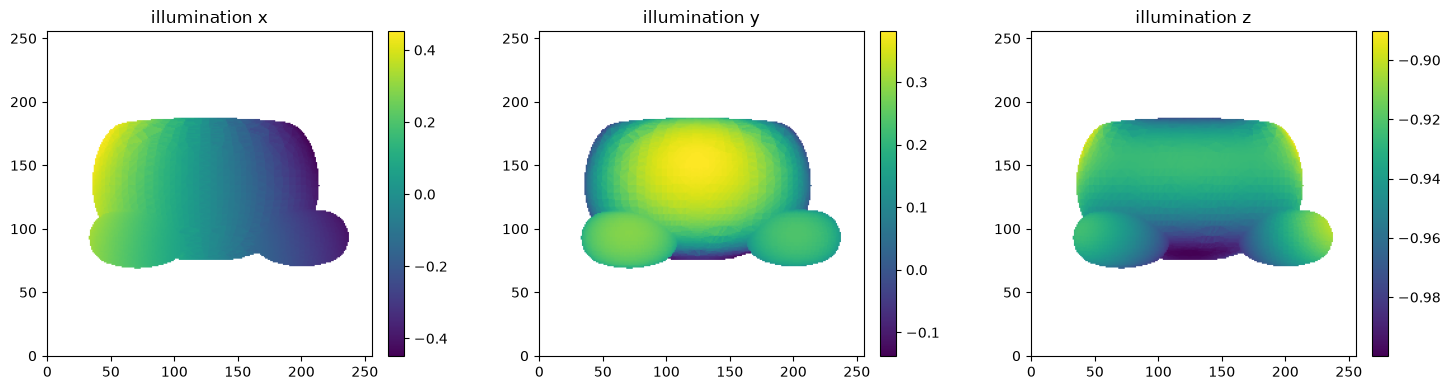

In [5]:
bx_img, by_img, bz_img = sample_face_scalars_to_images(
    hit_faces,
    [b_faces[:, 0], b_faces[:, 1], b_faces[:, 2]],
    rays.sample_shape,
)
plot_face_sampled_row(
    [bx_img, by_img, bz_img],
    ["illumination x", "illumination y", "illumination z"],
    figsize=(15, 4),
)


In [6]:
# Transient upstream thickness L_proxy and Beer–Lambert T_face
L_proxy = compute_face_upstream_thickness(mesh, light, eps=1e-4)
mu = 0.2
T_face = thickness_to_transmittance(L_proxy, mu=mu)

summarize_array("L_proxy", L_proxy)
summarize_array("T_face", T_face)


L_proxy: shape=(18162,), sum=172449.360411, min=0, max=15.6804981014, nnz=15075
T_face: shape=(18162,), sum=5468.17873743, min=0.0434519469071, max=1, nnz=18162


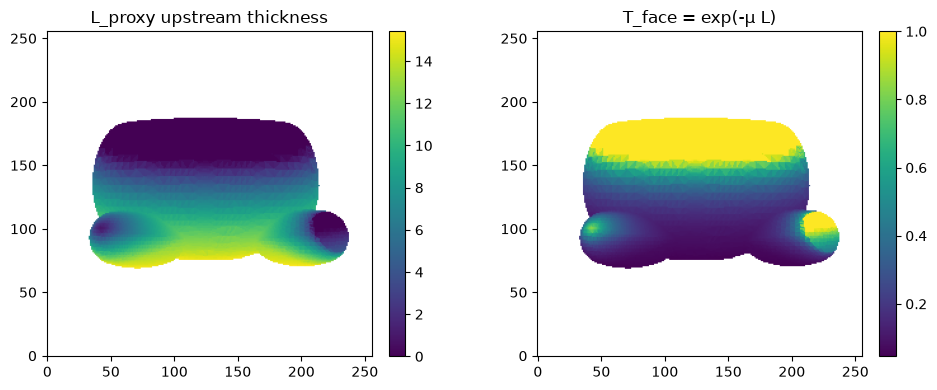

In [7]:
L_img, T_img = sample_face_scalars_to_images(
    hit_faces,
    [L_proxy, T_face],
    rays.sample_shape,
)
plot_face_sampled_row(
    [L_img, T_img],
    ["L_proxy upstream thickness", "T_face = exp(-μ L)"],
    figsize=(10, 4),
)


In [8]:
# Source intensity: directional vs point falloff modes
I_dir = source_intensity_at_faces(
    mesh,
    DirectionalLightConfig(propagation_direction=(0.0, 0.0, -1.0), intensity=1.0),
)
I_point_none = source_intensity_at_faces(
    mesh,
    PointLightConfig(position=(0.0, 0.0, 30.0), intensity=1.0, falloff="none"),
)
I_point_inv2 = source_intensity_at_faces(
    mesh,
    PointLightConfig(position=(0.0, 0.0, 30.0), intensity=100.0, falloff="inverse_square"),
)

for name, arr in [
    ("directional", I_dir),
    ("point none", I_point_none),
    ("point inv2", I_point_inv2),
]:
    summarize_array(name, arr)


directional: shape=(18162,), sum=18162, min=1, max=1, nnz=18162
point none: shape=(18162,), sum=18162, min=1, max=1, nnz=18162
point inv2: shape=(18162,), sum=1945.85350379, min=0.0733593576031, max=0.249988067449, nnz=18162


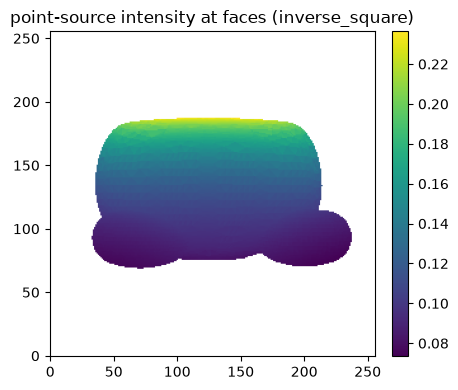

In [9]:
I_source_img = sample_face_values_to_image(
    hit_faces,
    I_point_inv2,
    background_value=np.nan,
).reshape(rays.sample_shape)

plot_face_sampled_row(
    [I_source_img],
    ["point-source intensity at faces (inverse_square)"],
    figsize=(5, 4),
)


## Next step

Run [`02b_3_end_to_end.ipynb`](./02b_3_end_to_end.ipynb) for the canonical six-step transient pipeline and factor-decomposition panel (`I_proxy ≈ source × T × g`).
